# import

In [1]:
import os
import gzip
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# configs

In [2]:
DATA_ROOT = "/home/carla_garage/data/VehicleTurningRoute/Town04_Rep0_Town04_Scenario4_80_route0_11_08_21_40_50"

# check measurement

In [3]:
def get_gz_json(file_path):
    with gzip.open(file_path, "rt", encoding="utf-8") as f:
        data = json.load(f)
    return data


m_path = os.path.join(DATA_ROOT, "measurements/0000.json.gz")
data = get_gz_json(m_path)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['pos_global', 'theta', 'speed', 'target_speed', 'speed_limit', 'target_point', 'target_point_next', 'command', 'next_command', 'aim_wp', 'route', 'route_original', 'changed_route', 'speed_reduced_by_obj_type', 'speed_reduced_by_obj_id', 'speed_reduced_by_obj_distance', 'steer', 'throttle', 'brake', 'control_brake', 'junction', 'vehicle_hazard', 'vehicle_affecting_id', 'light_hazard', 'walker_hazard', 'walker_affecting_id', 'stop_sign_hazard', 'stop_sign_close', 'walker_close', 'walker_close_id', 'angle', 'augmentation_translation', 'augmentation_rotation', 'ego_matrix'])


In [4]:
m_df = pd.DataFrame([data])
m_df.head()

,pos_global,theta,speed,target_speed,speed_limit,target_point,target_point_next,command,next_command,aim_wp,...,walker_hazard,walker_affecting_id,stop_sign_hazard,stop_sign_close,walker_close,walker_close_id,angle,augmentation_translation,augmentation_rotation,ego_matrix
0,"[347.78082275390625, -130.0367889404297]",1.687296,0.234638,1.360522,13.888889,"[11.468373667473315, 22.490800592453777]","[3.350478967005411, 33.4737121146053]",4,4,"[8.289028483366414, 5.311159429452823]",...,False,None,False,False,False,None,0.362773,-0.768646,-2.043749,"[[-0.11623653024435043, -0.9932214021682739, 0..."


In [5]:
measurement_dir = Path(DATA_ROOT + "/measurements")

rows = []

for file in sorted(measurement_dir.glob("*.json.gz")):
    with gzip.open(file, "rt", encoding="utf-8") as f:
        data = json.load(f)

    data["frame"] = file.stem   # frame id 추가
    rows.append(data)

df = pd.DataFrame(rows)

print(df.head())
print(df.columns)

                                 pos_global     theta     speed  target_speed  \
0  [347.78082275390625, -130.0367889404297]  1.687296  0.234638      1.360522   
1  [347.7808532714844, -130.03683471679688]  1.687304  0.091377      0.919084   
2   [347.7808837890625, -130.0368194580078]  1.687304  0.025316      0.854660   
3    [347.65478515625, -129.89627075195312]  1.764930  1.319132      2.067519   
4     [347.3173828125, -129.58543395996094]  1.939286  2.540030      3.201722   

   speed_limit                              target_point  \
0    13.888889  [11.468373667473315, 22.490800592453777]   
1    13.888889   [11.468610358464888, 22.49072988155449]   
2    13.888889  [11.468598750612296, 22.490761965989602]   
3    13.888889   [13.01593706576741, 21.437053495278466]   
4    13.888889    [16.12586397696456, 18.65131740609838]   

                          target_point_next  command  next_command  \
0     [3.350478967005411, 33.4737121146053]        4             4   
1    [3.3508

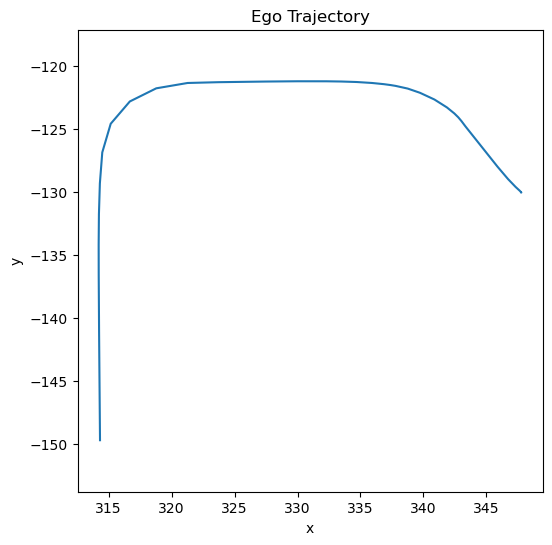

In [6]:
xs = df["pos_global"].apply(lambda x: x[0])
ys = df["pos_global"].apply(lambda x: x[1])

plt.figure(figsize=(6, 6))
plt.plot(xs, ys)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ego Trajectory")
plt.show()

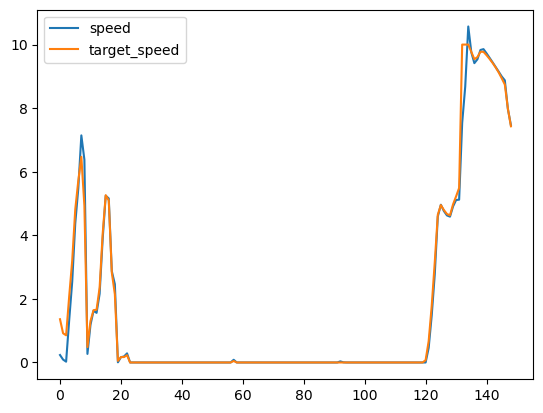

In [7]:
plt.plot(df["speed"], label="speed")
plt.plot(df["target_speed"], label="target_speed")
plt.legend()

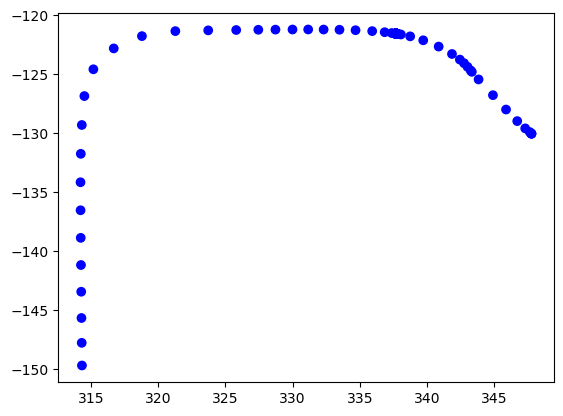

In [8]:
colors = df["vehicle_hazard"].map({True:"red", False:"blue"})

plt.scatter(xs, ys, c=colors)

# BEV Semantics

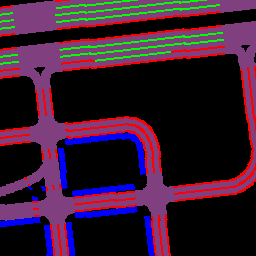

In [9]:
from PIL import Image

def visualize_semantic_mask(mask, color_map=None):
    """
    mask: (H, W) uint8/int array
    returns: RGB image (H, W, 3)
    """

    if color_map is None:
        color_map = {
            0: (0, 0, 0),         # black
            1: (128, 64, 128),   # road
            2: (0, 0, 255),      # vehicle
            3: (255, 0, 0),      # pedestrian
            4: (0, 255, 0),      # vegetation
            5: (255, 255, 0),    # lane
        }

    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id, color in color_map.items():
        rgb[mask == class_id] = color

    return rgb

test_img_path = os.path.join(DATA_ROOT, 'bev_semantics', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
Image.fromarray(rgb).show()

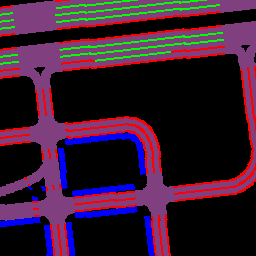

In [10]:
test_img_path = os.path.join(DATA_ROOT, 'bev_semantics_augmented', '0000.png')
mask = np.array(Image.open(test_img_path))
rgb = visualize_semantic_mask(mask)
Image.fromarray(rgb).show()

# lidar

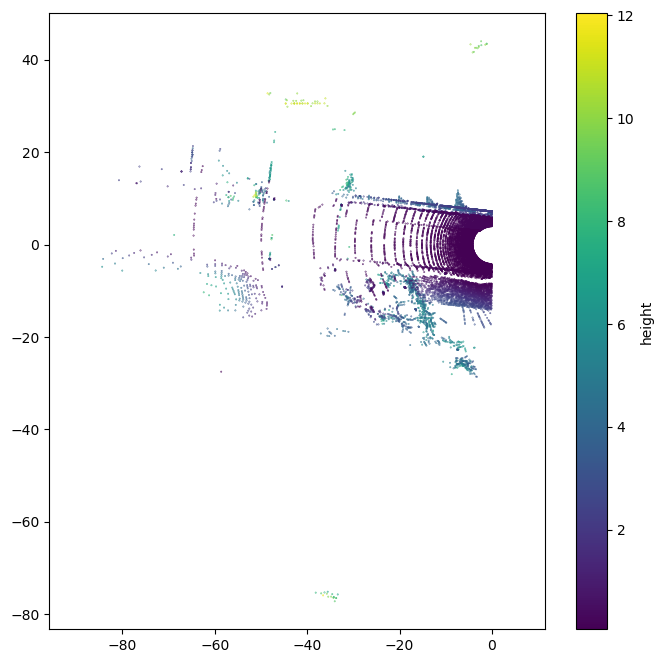

In [11]:
import laspy

test_lidar_path = os.path.join(DATA_ROOT, "lidar", "0000.laz")
las = laspy.read(test_lidar_path)

x = las.x
y = las.y
z = las.z

plt.figure(figsize=(8,8))
plt.scatter(x, y, s=0.1, c=z)
plt.axis("equal")
plt.colorbar(label="height")
plt.show()

In [14]:
import open3d as o3d

def lidar_bev_image(points, x_range=(-30, 30), y_range=(-30, 30), res=0.1):
    """
    points: (N, 3) or (N, 4), x/y/z lidar points
    returns BEV grayscale image
    """
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    mask = (
        (x >= x_range[0]) & (x < x_range[1]) &
        (y >= y_range[0]) & (y < y_range[1])
    )

    x = x[mask]
    y = y[mask]
    z = z[mask]

    W = int((x_range[1] - x_range[0]) / res)
    H = int((y_range[1] - y_range[0]) / res)

    x_img = ((x - x_range[0]) / res).astype(np.int32)
    y_img = ((y - y_range[0]) / res).astype(np.int32)

    bev = np.zeros((H, W), dtype=np.float32)

    z_norm = z - z.min()
    if z_norm.max() > 0:
        z_norm = z_norm / z_norm.max()

    bev[H - 1 - y_img, x_img] = np.maximum(bev[H - 1 - y_img, x_img], z_norm)

    bev = (bev * 255).astype(np.uint8)
    return bev


points = np.vstack([x, y, z]).T
bev = lidar_bev_image(points)
Image.fromarray(bev).save("/home/test.png")

# box, RGB, depth, Semantic

In [13]:

boxes = get_gz_json("/home/carla_garage/data/EnterActorFlowV2/Town12_Rep0_975_5_route0_11_08_13_28_32/boxes/0000.json.gz")
print(boxes)


[{'class': 'ego_car', 'extent': [2.44619083404541, 0.9183566570281982, 0.7451388239860535], 'position': [0.0, 0.0, 0.0], 'yaw': 0.0, 'num_points': -1, 'distance': -1, 'speed': 0.00016774729410675953, 'brake': 0.0, 'id': 3695, 'matrix': [[-0.9880388975143433, 0.15412288904190063, -0.005031882785260677, 2842.72021484375], [-0.15412122011184692, -0.98805171251297, -0.0007175241480581462, 6190.56982421875], [-0.005082346964627504, 6.657817721134052e-05, 0.9999870657920837, 372.2286376953125], [0.0, 0.0, 0.0, 1.0]]}]
